# 01 Data Cleaning and Feature Engineering

This notebook loads the raw tennis point data, performs cleaning, aggregates point-level data to match-level data, and saves a processed `analysis_df.csv` for later notebooks.

# Setup

Run this cell first so notebooks can import helpers from the `src/` folder.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

In [ ]:
from src.data_processing import safe_divide, get_categorical_counts, impute_zero_with_mean

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

You can upload files directly to your Colab environment using the following code. After running the cell, you will be prompted to choose a file from your local machine. Once uploaded, `data.csv` will be accessible in the current session.

In [ ]:
from google.colab import files

# Upload the file from your local system
uploaded = files.upload()

# If you want to confirm the file is uploaded and available
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving 2019-usopen-points.csv to 2019-usopen-points.csv
Saving 2020-usopen-points.csv to 2020-usopen-points.csv
Saving 2021-usopen-points.csv to 2021-usopen-points.csv
Saving 2022-usopen-points.csv to 2022-usopen-points.csv
Saving 2023-usopen-points.csv to 2023-usopen-points.csv
Saving 2024-usopen-points.csv to 2024-usopen-points.csv
User uploaded file "2019-usopen-points.csv" with length 7480927 bytes
User uploaded file "2020-usopen-points.csv" with length 7074131 bytes
User uploaded file "2021-usopen-points.csv" with length 7727334 bytes
User uploaded file "2022-usopen-points.csv" with length 7572634 bytes
User uploaded file "2023-usopen-points.csv" with length 7304490 bytes
User uploaded file "2024-usopen-points.csv" with length 7260912 bytes


After uploading, you can then read the CSV file into a pandas DataFrame:

In [ ]:
import io

# Create a dictionary to store individual DataFrames
all_dfs = {}

# Iterate through each uploaded file and read it into a DataFrame
for filename, content in uploaded.items():
  print(f'Reading file: {filename}')
  # Assuming all uploaded files are CSVs, you can adjust for other formats
  df_name = 'df'+ filename.split('-')[0] # Use filename without extension as df name
  all_dfs[df_name] = pd.read_csv(io.StringIO(content.decode('utf-8')))
  print(f'Successfully loaded {filename} into DataFrame: {df_name}')

Reading file: 2019-usopen-points.csv
Successfully loaded 2019-usopen-points.csv into DataFrame: df2019
Reading file: 2020-usopen-points.csv
Successfully loaded 2020-usopen-points.csv into DataFrame: df2020
Reading file: 2021-usopen-points.csv
Successfully loaded 2021-usopen-points.csv into DataFrame: df2021
Reading file: 2022-usopen-points.csv
Successfully loaded 2022-usopen-points.csv into DataFrame: df2022
Reading file: 2023-usopen-points.csv
Successfully loaded 2023-usopen-points.csv into DataFrame: df2023
Reading file: 2024-usopen-points.csv
Successfully loaded 2024-usopen-points.csv into DataFrame: df2024


In [ ]:
all_dfs['df2019'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47893 entries, 0 to 47892
Data columns (total 65 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   match_id            47893 non-null  object 
 1   ElapsedTime         47893 non-null  object 
 2   SetNo               47893 non-null  int64  
 3   P1GamesWon          47893 non-null  int64  
 4   P2GamesWon          47893 non-null  int64  
 5   SetWinner           47893 non-null  int64  
 6   GameNo              47893 non-null  int64  
 7   GameWinner          47893 non-null  int64  
 8   PointNumber         47893 non-null  object 
 9   PointWinner         47893 non-null  int64  
 10  PointServer         47893 non-null  int64  
 11  Speed_KMH           47893 non-null  int64  
 12  Rally               0 non-null      float64
 13  P1Score             47893 non-null  object 
 14  P2Score             47893 non-null  object 
 15  P1Momentum          47893 non-null  int64  
 16  P2Mo

First, let's check if all DataFrames have the same columns. We'll compare the columns of `df2019` with the others.

In [ ]:
# Get column names for df2019
ref_columns = set(all_dfs['df2019'].columns)

# Check if all other DataFrames have the same columns
consistent_columns = True
for name, df in all_dfs.items():
  if name != 'df2019': # Skip comparing with itself
    current_columns = set(df.columns)
    if ref_columns != current_columns:
      print(f"DataFrame '{name}' has different columns than 'df2019'.")
      print(f"Columns in 'df2019': {ref_columns}")
      print(f"Columns in '{name}': {current_columns}")
      consistent_columns = False
    else:
      print(f"DataFrame '{name}' has consistent columns with 'df2019'.")

if consistent_columns:
  print("\nAll DataFrames have consistent column names.")
else:
  print("\nSome DataFrames have inconsistent column names. You might need to preprocess them before merging.")

DataFrame 'df2020' has consistent columns with 'df2019'.
DataFrame 'df2021' has consistent columns with 'df2019'.
DataFrame 'df2022' has consistent columns with 'df2019'.
DataFrame 'df2023' has consistent columns with 'df2019'.
DataFrame 'df2024' has consistent columns with 'df2019'.

All DataFrames have consistent column names.


Next, let's check for data type consistency across common columns. We'll focus on `df2019` as the reference.

In [ ]:
# Get data types for df2019
ref_dtypes = all_dfs['df2019'].dtypes

consistent_dtypes = True
for name, df in all_dfs.items():
  if name == 'df2019':
    continue

  current_dtypes = df.dtypes
  for col in ref_columns:
    if col in current_dtypes and ref_dtypes[col] != current_dtypes[col]:
      print(f"Data type mismatch for column '{col}' between 'df2019' ({ref_dtypes[col]}) and '{name}' ({current_dtypes[col]}).")
      consistent_dtypes = False

if consistent_dtypes:
  print("\nAll DataFrames have consistent data types for common columns.")
else:
  print("\nSome DataFrames have inconsistent data types for common columns. You might need to cast them before merging.")



All DataFrames have consistent data types for common columns.


Once these checks pass, you can combine them using `pd.concat()`. If there are inconsistencies, you'll need to address them first.

In [ ]:
all_points = pd.concat(all_dfs.values(), ignore_index=True)

all_points.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278894 entries, 0 to 278893
Data columns (total 65 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   match_id            278894 non-null  object 
 1   ElapsedTime         278894 non-null  object 
 2   SetNo               278894 non-null  int64  
 3   P1GamesWon          278894 non-null  int64  
 4   P2GamesWon          278894 non-null  int64  
 5   SetWinner           278894 non-null  int64  
 6   GameNo              278894 non-null  int64  
 7   GameWinner          278894 non-null  int64  
 8   PointNumber         278894 non-null  object 
 9   PointWinner         278894 non-null  int64  
 10  PointServer         278894 non-null  int64  
 11  Speed_KMH           278894 non-null  int64  
 12  Rally               0 non-null       float64
 13  P1Score             278894 non-null  object 
 14  P2Score             278894 non-null  object 
 15  P1Momentum          278894 non-nul

In [ ]:
df1 = all_points.copy()

In [ ]:
empty_columns = [col for col in df1.columns if df1[col].isnull().all()]

if empty_columns:
    print(f"Dropping the following completely empty columns: {empty_columns}")
    df1.drop(columns=empty_columns, inplace=True)
    print("Empty columns removed successfully.")
else:
    print("No completely empty columns found in df1.")

df1.info()

Dropping the following completely empty columns: ['Rally', 'P1FirstSrvIn', 'P2FirstSrvIn', 'P1FirstSrvWon', 'P2FirstSrvWon', 'P1SecondSrvIn', 'P2SecondSrvIn', 'P1SecondSrvWon', 'P2SecondSrvWon', 'P1ForcedError', 'P2ForcedError', 'Serve_Direction', 'Winner_FH', 'Winner_BH', 'ServingTo', 'P1TurningPoint', 'P2TurningPoint']
Empty columns removed successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278894 entries, 0 to 278893
Data columns (total 48 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   match_id            278894 non-null  object 
 1   ElapsedTime         278894 non-null  object 
 2   SetNo               278894 non-null  int64  
 3   P1GamesWon          278894 non-null  int64  
 4   P2GamesWon          278894 non-null  int64  
 5   SetWinner           278894 non-null  int64  
 6   GameNo              278894 non-null  int64  
 7   GameWinner          278894 non-null  int64  
 8   PointNumber         27889

In [ ]:
#remove column 'History'(i can't find the meaning of this column so won't use it) and 'Speed_KMH'(repeat with Speed_MPH)
df1 = df1.drop(columns=['History', 'Speed_KMH'])

In [ ]:
df1['PointNumber'].unique()

array(['0X', '0Y', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10',
       '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21',
       '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32',
       '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43',
       '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54',
       '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65',
       '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76',
       '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87',
       '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98',
       '99', '100', '101', '102', '103', '104', '105', '106', '107',
       '108', '109', '110', '111', '112', '113', '114', '115', '116',
       '117', '118', '119', '120', '121', '122', '123', '124', '125',
       '126', '127', '128', '129', '130', '131', '132', '133', '134',
       '135', '136', '137', '138', '139', '140', '141', '142', '143

In [ ]:
df1[df1['PointNumber'] == '20Y']

,match_id,ElapsedTime,SetNo,P1GamesWon,P2GamesWon,SetWinner,GameNo,GameWinner,PointNumber,PointWinner,...,ServeIndicator,ServeNumber,WinnerType,WinnerShotType,P1DistanceRun,P2DistanceRun,RallyCount,ServeWidth,ServeDepth,ReturnDepth
150222,2022-usopen-1143,0,1,0,0,0,5,0,20Y,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
150490,2022-usopen-1144,0,1,0,0,0,3,0,20Y,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN


In [ ]:
#remove rows that ElapsedTime = 0, which are extral records
df1 = df1[df1['ElapsedTime'] != '0']

In [ ]:
df1[(df1['PointNumber'] == '0X') | (df1['PointNumber'] == '0Y')]

,match_id,ElapsedTime,SetNo,P1GamesWon,P2GamesWon,SetWinner,GameNo,GameWinner,PointNumber,PointWinner,...,ServeIndicator,ServeNumber,WinnerType,WinnerShotType,P1DistanceRun,P2DistanceRun,RallyCount,ServeWidth,ServeDepth,ReturnDepth
0,2019-usopen-1101,0:00:00,1,0,0,0,1,0,0X,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
1,2019-usopen-1101,0:00:00,1,0,0,0,1,0,0Y,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
166,2019-usopen-1102,0:00:00,1,0,0,0,1,0,0X,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
167,2019-usopen-1102,0:00:00,1,0,0,0,1,0,0Y,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
402,2019-usopen-1103,0:00:00,1,0,0,0,1,0,0X,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278416,2024-usopen-2601,0:00:00,1,0,0,0,1,0,0Y,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
278591,2024-usopen-2602,0:00:00,1,0,0,0,1,0,0X,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
278592,2024-usopen-2602,0:00:00,1,0,0,0,1,0,0Y,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
278725,2024-usopen-2701,0:00:00,1,0,0,0,1,0,0X,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN


In [ ]:
#remove rows that has PointNumber = '0X' or '0Y'. these are rows used to separate different matches
df1 = df1[(df1['PointNumber'] != '0X') & (df1['PointNumber'] != '0Y')]

In [ ]:
df1['PointNumber'].unique()

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34',
       '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45',
       '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56',
       '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67',
       '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78',
       '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89',
       '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100',
       '101', '102', '103', '104', '105', '106', '107', '108', '109',
       '110', '111', '112', '113', '114', '115', '116', '117', '118',
       '119', '120', '121', '122', '123', '124', '125', '126', '127',
       '128', '129', '130', '131', '132', '133', '134', '135', '136',
       '137', '138', '139', '140', '141', '142', '143', '144', '1

In [ ]:
df1['P1Score'].unique()

array(['15', '30', '40', '0', 'AD', '1', '2', '3', '4', '5', '6', '7',
       '8', '9', '10', '11', '12', '13', '14'], dtype=object)

In [ ]:
df1['P2Score'].unique()

array(['0', '15', '30', '40', 'AD', '1', '2', '3', '4', '5', '6', '7',
       '8', '9', '10', '11', '12', '13', '14'], dtype=object)

In [ ]:
#the Score has both string and int in tennis, we can't change P1Score and P2Score to int64 datatype. We won't use these two variables later.
#we only change PointNumber from object to int64type
df1['PointNumber'] = pd.to_numeric(df1['PointNumber'], errors='coerce')

In [ ]:
df1.isna().sum()

,0
match_id,0
ElapsedTime,0
SetNo,0
P1GamesWon,0
P2GamesWon,0
SetWinner,0
GameNo,0
GameWinner,0
PointNumber,0
PointWinner,0


In [ ]:
(df1['RallyCount'] == 0).sum()

np.int64(35826)

In [ ]:

cols = [
  'SetNo',
  'RallyCount',
  'ServeIndicator',
  'ServeNumber',
  'PointNumber',
  'P1PointsWon',
  'P2PointsWon',
  'P1Ace',
  'P2Ace',
  'P1Winner',
  'P2Winner',
  'P1DoubleFault',
  'P2DoubleFault',
  'P1UnfErr',
  'P2UnfErr',
  'P1NetPoint',
  'P2NetPoint',
  'P1NetPointWon',
  'P2NetPointWon',
  'P1BreakPoint',
  'P2BreakPoint',
  'P1BreakPointWon',
  'P2BreakPointWon',
  'P1DistanceRun',
  'P2DistanceRun',
  'Speed_MPH'
]


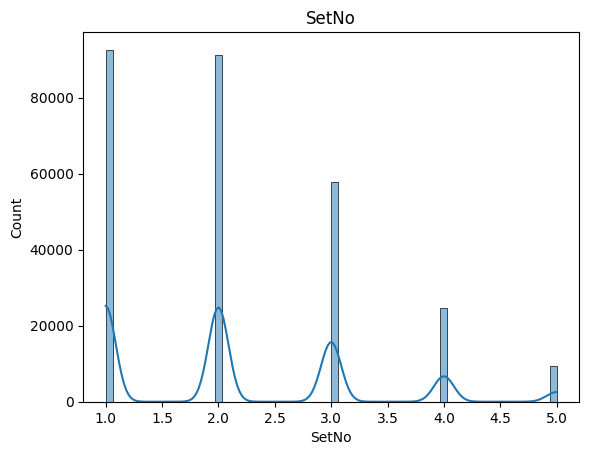

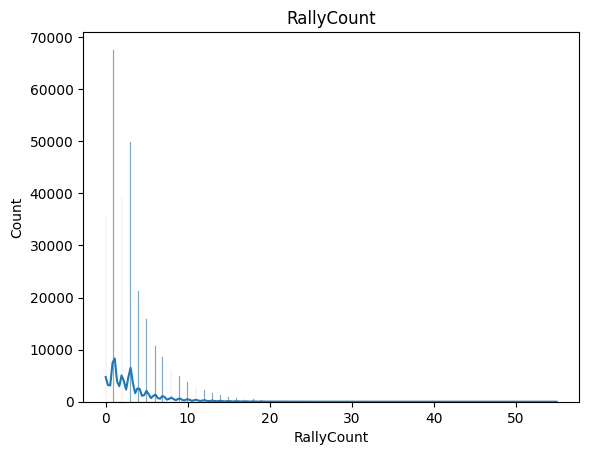

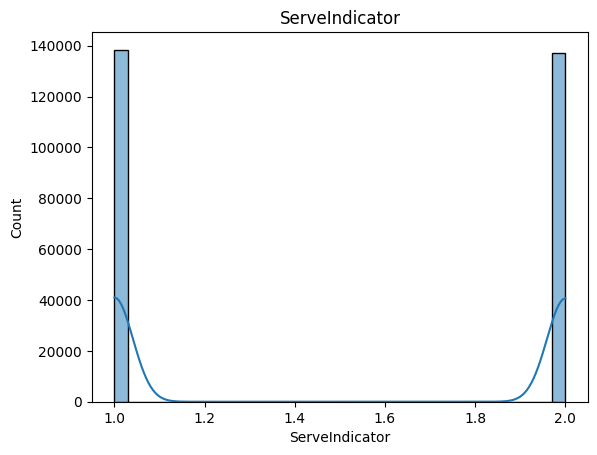

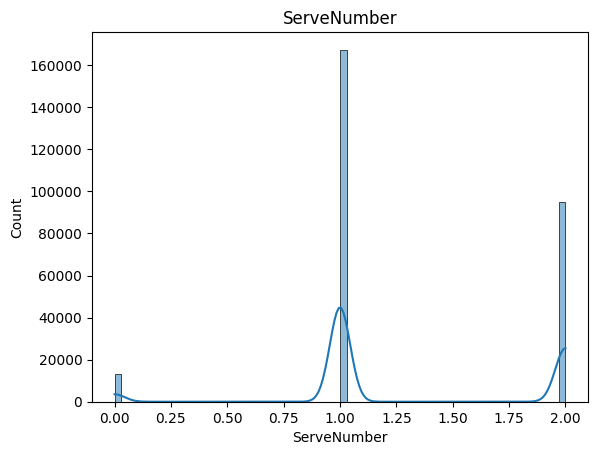

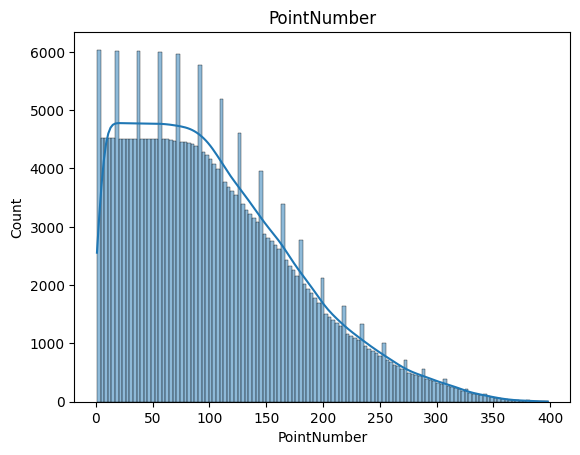

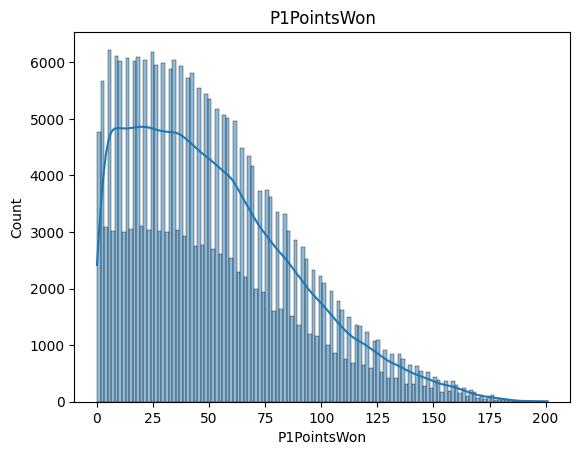

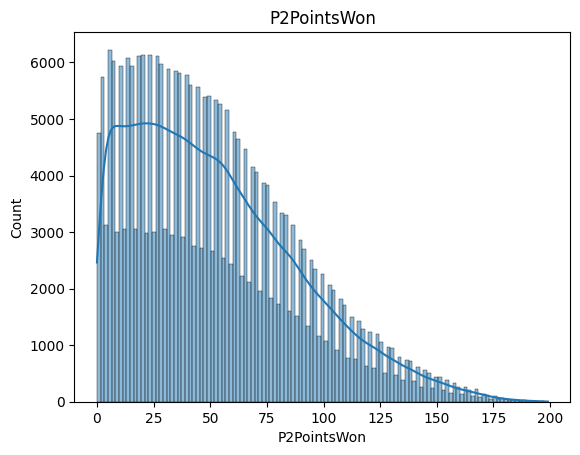

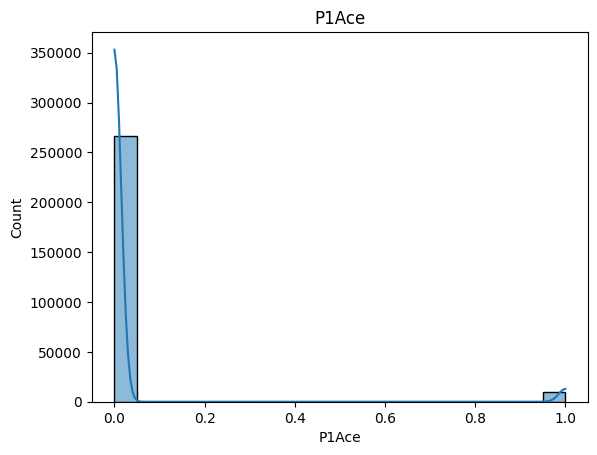

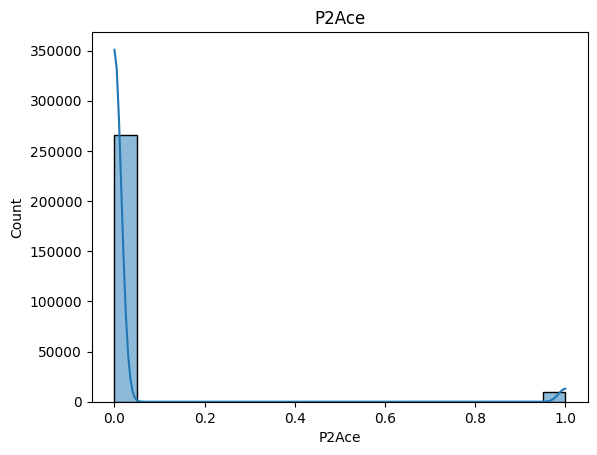

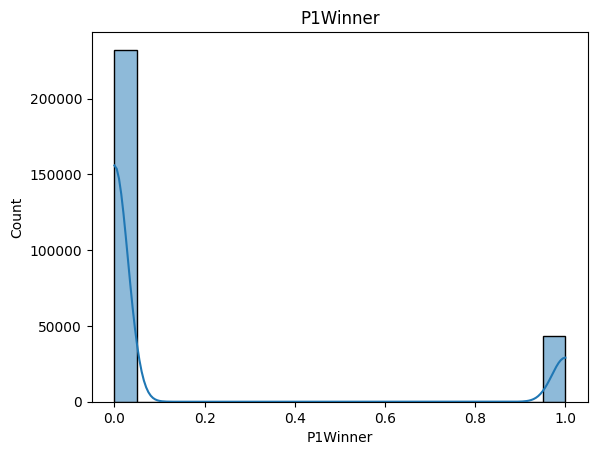

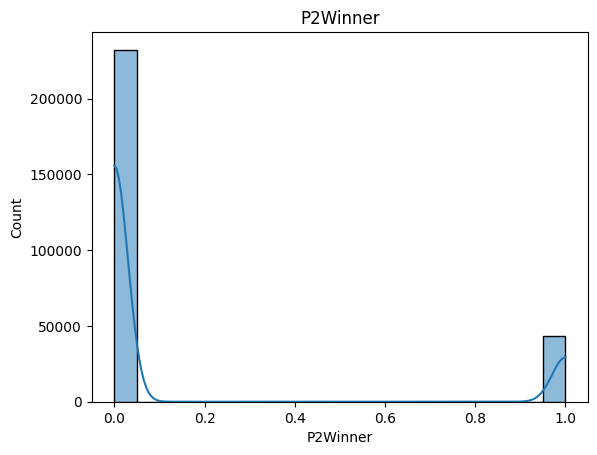

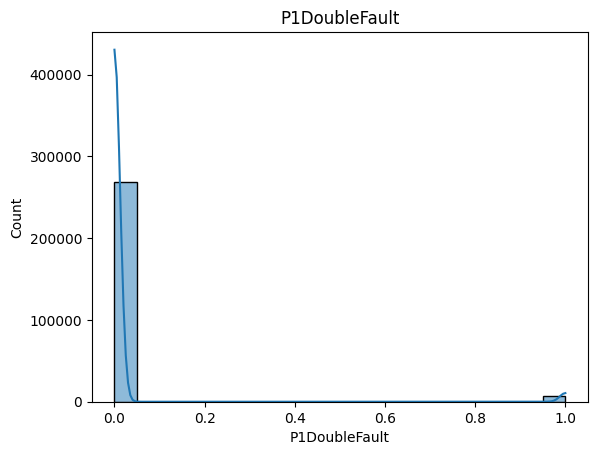

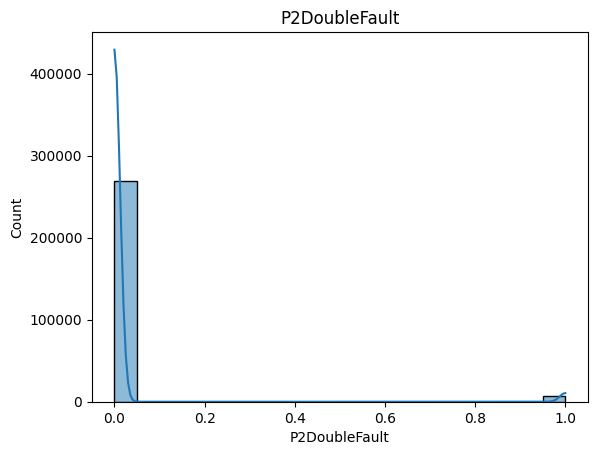

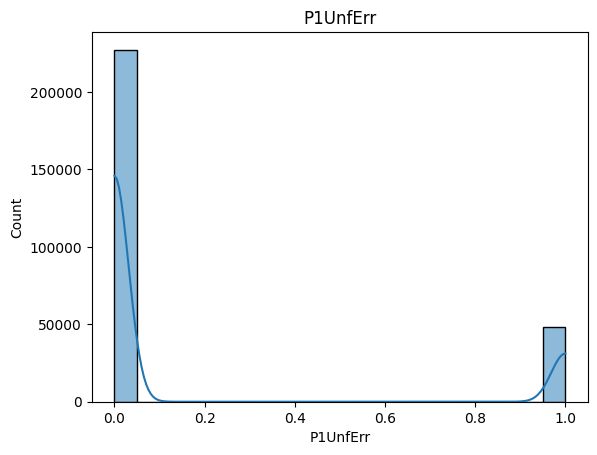

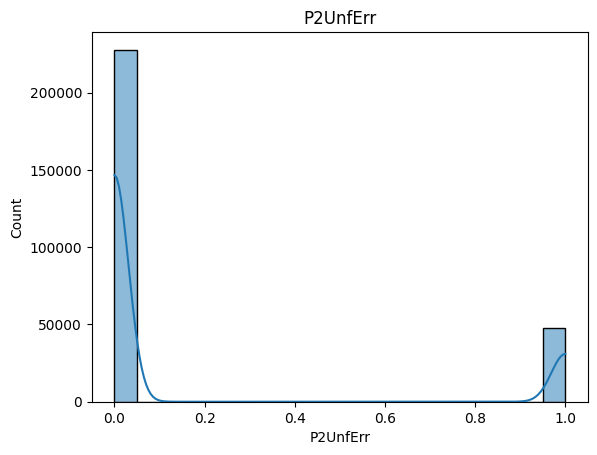

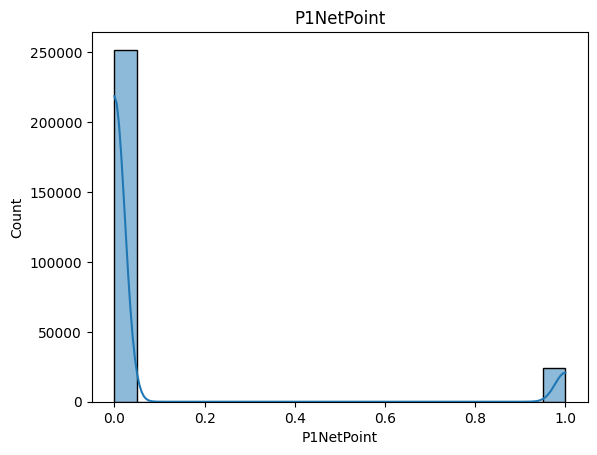

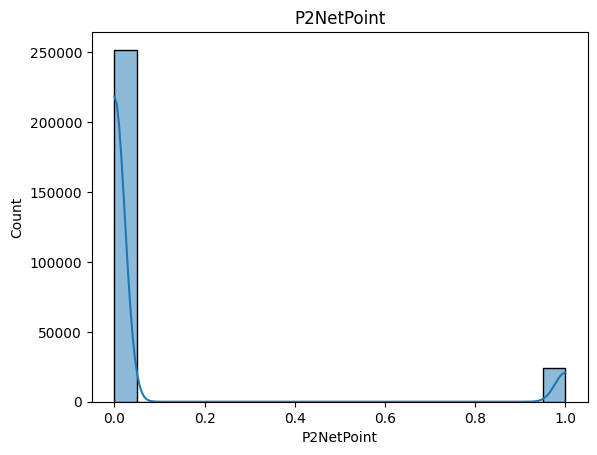

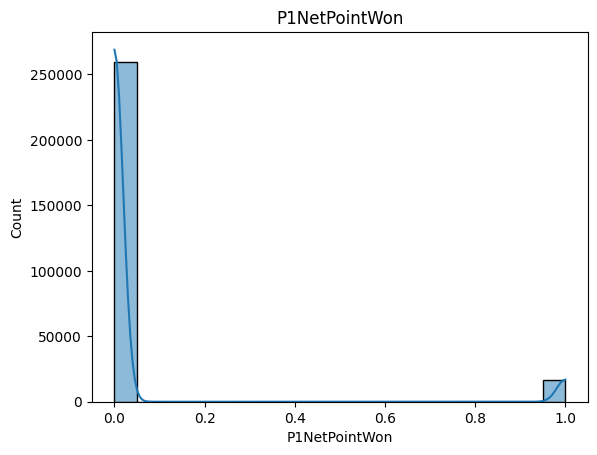

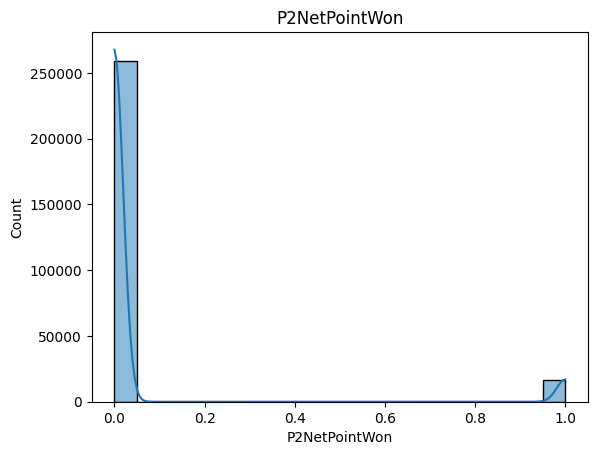

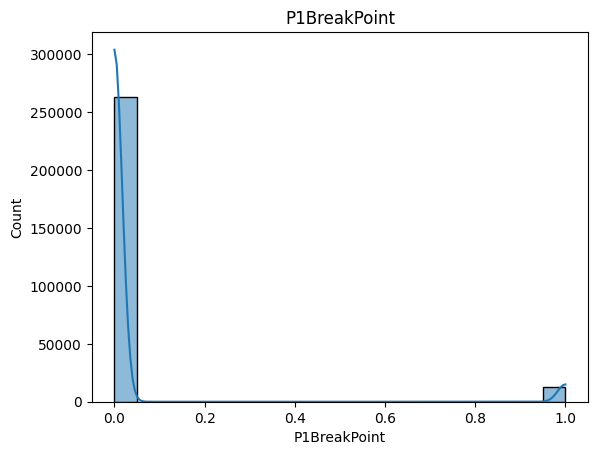

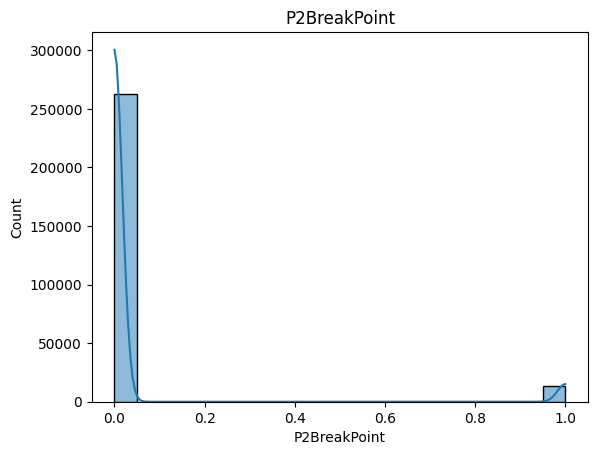

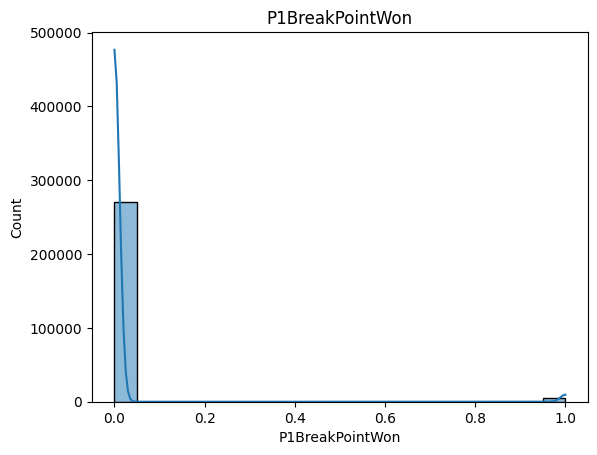

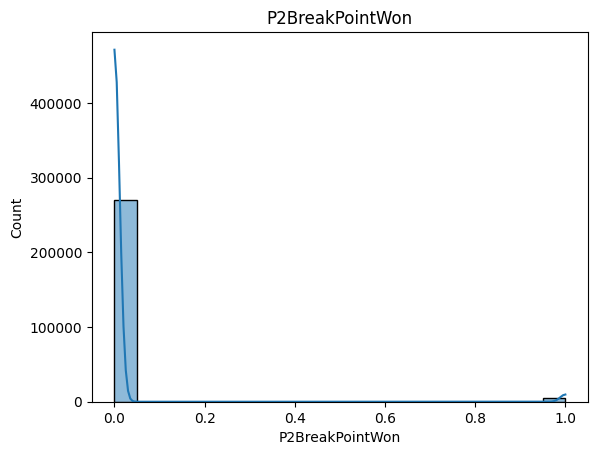

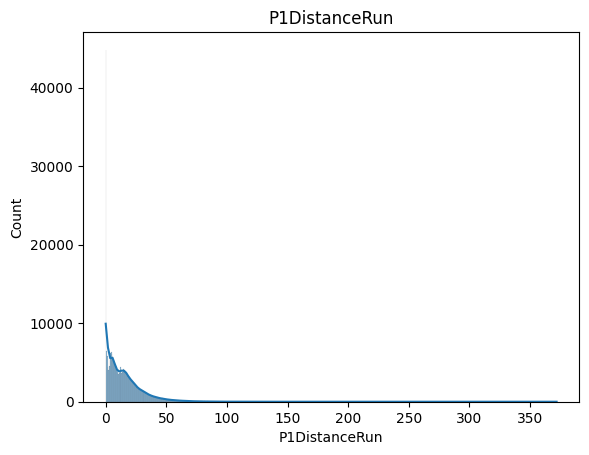

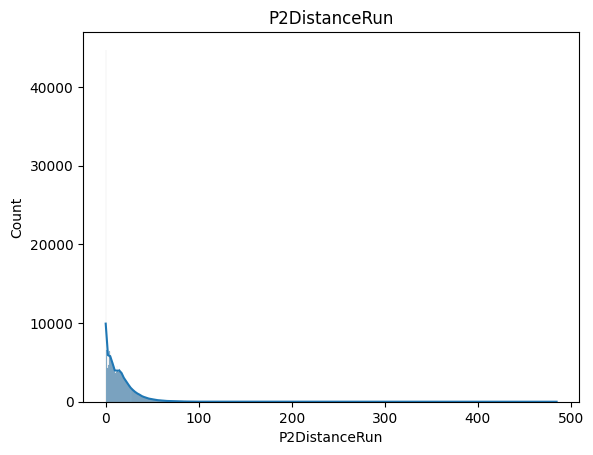

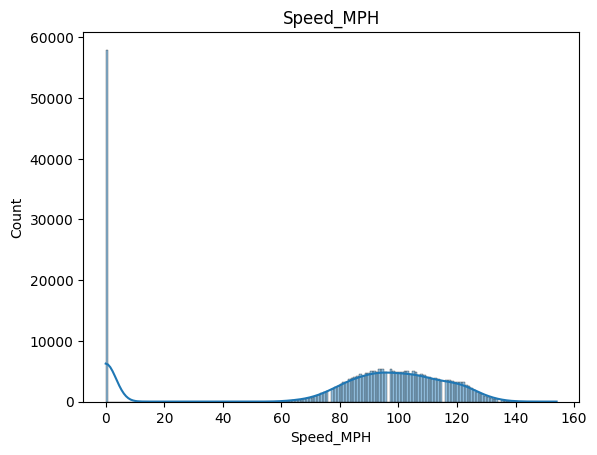

In [ ]:
#get the core cols and their plots to detect abnormal data
for col in cols:
    plt.figure()
    sns.histplot(df1[col], kde=True)
    plt.title(col)
    plt.show()


In [ ]:
serve_zero_df = df1[df1['ServeNumber'] == 0]
print(f"Number of rows with ServeNumber = 0: {len(serve_zero_df)}")

# Check if these are associated with specific events like Double Faults
display(serve_zero_df[['match_id', 'PointNumber', 'P1DoubleFault', 'P2DoubleFault', 'PointWinner', 'RallyCount']].head(10))

Number of rows with ServeNumber = 0: 13221


,match_id,PointNumber,P1DoubleFault,P2DoubleFault,PointWinner,RallyCount
3,2019-usopen-1101,2,1,0,2,0
21,2019-usopen-1101,20,0,1,1,0
80,2019-usopen-1101,79,0,1,1,0
81,2019-usopen-1101,80,0,1,1,0
97,2019-usopen-1101,96,0,1,1,0
106,2019-usopen-1101,105,1,0,2,0
117,2019-usopen-1101,116,1,0,2,0
156,2019-usopen-1101,155,0,1,1,0
168,2019-usopen-1102,1,1,0,2,0
188,2019-usopen-1102,21,1,0,2,0


In [ ]:
# Check if every ServeNumber = 0 row is a double fault
exceptions = df1[(df1['ServeNumber'] == 0) & (df1['P1DoubleFault'] == 0) & (df1['P2DoubleFault'] == 0)]

if exceptions.empty:
    print("Confirmed: All rows where ServeNumber = 0 are indeed Double Faults.")
else:
    print(f"Found {len(exceptions)} rows where ServeNumber = 0 but no Double Fault was recorded.")
    display(exceptions.head())

Confirmed: All rows where ServeNumber = 0 are indeed Double Faults.


In [ ]:
df1[(df1['P1Ace'] == 1) | (df1['P2Ace'] == 1)]['RallyCount']

,RallyCount
12,1
45,1
66,1
86,1
90,1
...,...
278771,1
278774,1
278819,1
278834,1


In [ ]:
# Replace 0 with NaN so we can use fillna
df1.loc[df1['RallyCount'] == 0, 'RallyCount'] = np.nan

# Create the ace flag
df1['is_ace'] = ((df1['P1Ace'] == 1) | (df1['P2Ace'] == 1)).astype(int)

# Instead of an 'if' statement, use .loc to fill RallyCount for aces
# Since an ace is by definition 1 shot, we can safely fill these NaNs with 1
df1.loc[(df1['is_ace'] == 1) & (df1['RallyCount'].isna()), 'RallyCount'] = 1

In [ ]:
df1['RallyCount'].isna().sum()

np.int64(34193)

In [ ]:
# Now use the grouping logic for the remaining non-ace NaNs
df1['RallyCount'] = df1['RallyCount'].fillna(
    df1.groupby(['SetNo', 'ServeNumber'])['RallyCount'].transform('mean')
)

# Clean up temporary column
df1.drop(columns=['is_ace'], inplace=True)

print(f"Remaining NaNs in RallyCount: {df1['RallyCount'].isna().sum()}")

Remaining NaNs in RallyCount: 7709


In [ ]:
# Identify why some groups failed (they had no non-null values to average)
remaining_nans = df1['RallyCount'].isna().sum()
print(f"Remaining NaNs before fallback: {remaining_nans}")

df1['RallyCount'] = df1['RallyCount'].fillna(
    df1.groupby(['SetNo'])['RallyCount'].transform('mean')
)

print(f"Final missing RallyCount values: {df1['RallyCount'].isna().sum()}")
display(df1['RallyCount'].describe())

Remaining NaNs before fallback: 7709
Final missing RallyCount values: 0


,RallyCount
count,275712.000000
mean,3.664362
std,3.200256
min,1.000000
25%,1.000000
50%,3.000000
75%,4.239705
max,55.000000


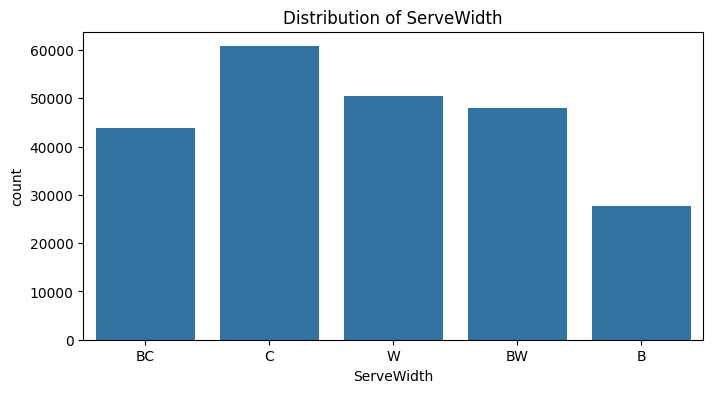

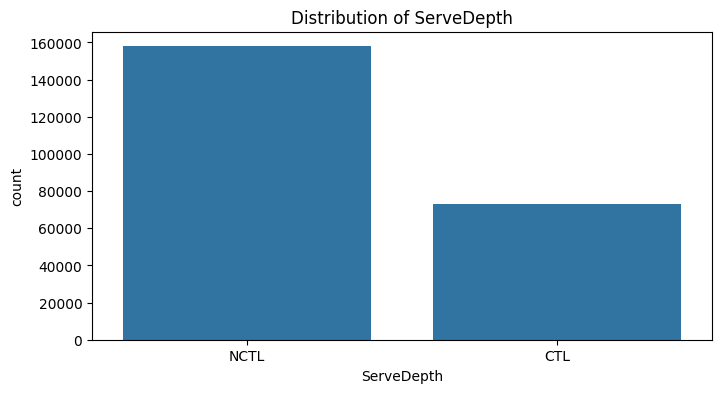

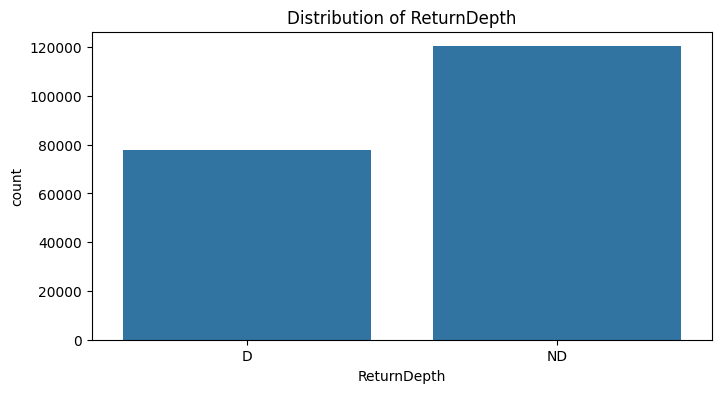

In [ ]:
col_c = ['ServeWidth', 'ServeDepth', 'ReturnDepth']

# Plotting categorical counts individually to avoid the concatenation error
for col in col_c:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df1, x=col)
    plt.title(f'Distribution of {col}')
    plt.show()

In [ ]:
df1[col_c].isna().sum()

,0
ServeWidth,44749
ServeDepth,44749
ReturnDepth,77483


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 275712 entries, 2 to 278893
Data columns (total 46 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   match_id            275712 non-null  object 
 1   ElapsedTime         275712 non-null  object 
 2   SetNo               275712 non-null  int64  
 3   P1GamesWon          275712 non-null  int64  
 4   P2GamesWon          275712 non-null  int64  
 5   SetWinner           275712 non-null  int64  
 6   GameNo              275712 non-null  int64  
 7   GameWinner          275712 non-null  int64  
 8   PointNumber         275712 non-null  int64  
 9   PointWinner         275712 non-null  int64  
 10  PointServer         275712 non-null  int64  
 11  P1Score             275712 non-null  object 
 12  P2Score             275712 non-null  object 
 13  P1Momentum          275712 non-null  int64  
 14  P2Momentum          275712 non-null  int64  
 15  P1PointsWon         275712 non-null  in

In [ ]:
# Aggregate to match-level data
match_df = df1.groupby('match_id').agg(
    points_played=('PointNumber', 'max'),
    rallies_count=('RallyCount', 'sum'),
    sets_played=('SetNo', 'max'),
    p1_points_won=('P1PointsWon', 'max'),
    p2_points_won=('P2PointsWon', 'max'),
    p1_aces=('P1Ace', 'sum'),
    p2_aces=('P2Ace', 'sum'),
    p1_winners=('P1Winner', 'sum'),
    p2_winners=('P2Winner', 'sum'),
    p1_double_faults=('P1DoubleFault', 'sum'),
    p2_double_faults=('P2DoubleFault', 'sum'),
    p1_unforced_errors=('P1UnfErr', 'sum'),
    p2_unforced_errors=('P2UnfErr', 'sum'),
    p1_net_points=('P1NetPoint', 'sum'),
    p2_net_points=('P2NetPoint', 'sum'),
    p1_net_points_won=('P1NetPointWon', 'sum'),
    p2_net_points_won=('P2NetPointWon', 'sum'),
    p1_breakpoints=('P1BreakPoint', 'sum'),
    p2_breakpoints=('P2BreakPoint', 'sum'),
    p1_breakpoints_won=('P1BreakPointWon', 'sum'),
    p2_breakpoints_won=('P2BreakPointWon', 'sum'),
    p1_distance_run=('P1DistanceRun', 'sum'),
    p2_distance_run=('P2DistanceRun', 'sum'),
    max_serve_speed_mph=('Speed_MPH', 'max')
).reset_index()


In [ ]:
def get_categorical_counts(df, col_name):
    # Create dummy variables for the specific column
    dummies = pd.get_dummies(df[col_name], prefix=col_name)
    # Add match_id and ServeIndicator to keep track of who did what
    temp_df = pd.concat([df[['match_id', 'ServeIndicator']], dummies], axis=1)

    # Aggregate for Player 1 (ServeIndicator == 1)
    p1_counts = temp_df[temp_df['ServeIndicator'] == 1].groupby('match_id').sum().drop(columns='ServeIndicator', errors='ignore').add_prefix('p1_')
    # Aggregate for Player 2 (ServeIndicator == 2)
    p2_counts = temp_df[temp_df['ServeIndicator'] == 2].groupby('match_id').sum().drop(columns='ServeIndicator', errors='ignore').add_prefix('p2_')

    return p1_counts, p2_counts

# Process ServeWidth, ServeDepth, and ReturnDepth
for feature in ['ServeWidth', 'ServeDepth', 'ReturnDepth']:
    p1_feat, p2_feat = get_categorical_counts(df1, feature)
    match_df = match_df.merge(p1_feat, on='match_id', how='left').merge(p2_feat, on='match_id', how='left')

# Fill NaNs with 0 (for matches where a certain type of serve/return never happened)
match_df = match_df.fillna(0)

print("New categorical aggregation columns added to match_df:")
print([c for c in match_df.columns if any(x in c for x in ['ServeWidth', 'ServeDepth', 'ReturnDepth'])])
display(match_df.head())

New categorical aggregation columns added to match_df:
['p1_ServeWidth_B', 'p1_ServeWidth_BC', 'p1_ServeWidth_BW', 'p1_ServeWidth_C', 'p1_ServeWidth_W', 'p2_ServeWidth_B', 'p2_ServeWidth_BC', 'p2_ServeWidth_BW', 'p2_ServeWidth_C', 'p2_ServeWidth_W', 'p1_ServeDepth_CTL', 'p1_ServeDepth_NCTL', 'p2_ServeDepth_CTL', 'p2_ServeDepth_NCTL', 'p1_ReturnDepth_D', 'p1_ReturnDepth_ND', 'p2_ReturnDepth_D', 'p2_ReturnDepth_ND']


,match_id,points_played,rallies_count,sets_played,p1_points_won,p2_points_won,p1_aces,p2_aces,p1_winners,p2_winners,...,p2_ServeWidth_C,p2_ServeWidth_W,p1_ServeDepth_CTL,p1_ServeDepth_NCTL,p2_ServeDepth_CTL,p2_ServeDepth_NCTL,p1_ReturnDepth_D,p1_ReturnDepth_ND,p2_ReturnDepth_D,p2_ReturnDepth_ND
0,2019-usopen-1101,164,763.876306,3,94,70,4,5,25,25,...,15,23,26.0,44.0,31,56,22.0,33.0,40,32
1,2019-usopen-1102,234,858.720159,4,107,127,24,10,45,49,...,43,18,44.0,71.0,30,83,23.0,58.0,33,56
2,2019-usopen-1103,233,535.587269,4,129,104,9,10,38,34,...,0,0,0.0,0.0,0,0,0.0,0.0,0,0
3,2019-usopen-1104,167,378.892532,3,72,95,2,4,20,30,...,0,0,0.0,0.0,0,0,0.0,0.0,0,0
4,2019-usopen-1105,270,1072.025422,4,142,128,15,2,35,28,...,20,16,53.0,80.0,32,79,51.0,56.0,44,56


In [ ]:
match_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             1510 non-null   object 
 1   points_played        1510 non-null   int64  
 2   rallies_count        1510 non-null   float64
 3   sets_played          1510 non-null   int64  
 4   p1_points_won        1510 non-null   int64  
 5   p2_points_won        1510 non-null   int64  
 6   p1_aces              1510 non-null   int64  
 7   p2_aces              1510 non-null   int64  
 8   p1_winners           1510 non-null   int64  
 9   p2_winners           1510 non-null   int64  
 10  p1_double_faults     1510 non-null   int64  
 11  p2_double_faults     1510 non-null   int64  
 12  p1_unforced_errors   1510 non-null   int64  
 13  p2_unforced_errors   1510 non-null   int64  
 14  p1_net_points        1510 non-null   int64  
 15  p2_net_points        1510 non-null   i

In [ ]:
#remove rows that has sets_played == 1, or points_played < 48
match_df = match_df[match_df['sets_played'] != 1]
match_df = match_df[match_df['points_played'] >= 48]

<Axes: xlabel='points_played', ylabel='Count'>

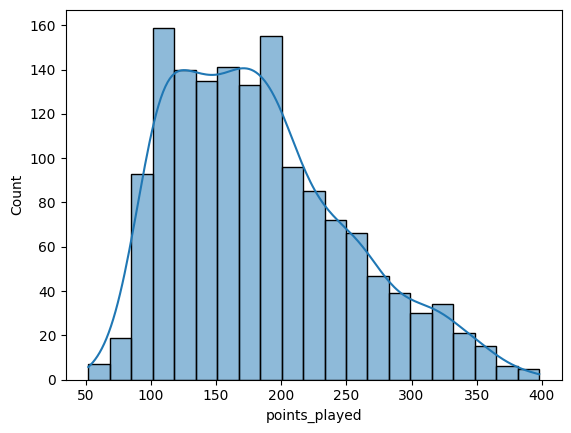

In [ ]:
sns.histplot(match_df['points_played'], kde=True)

<Axes: xlabel='sets_played', ylabel='Count'>

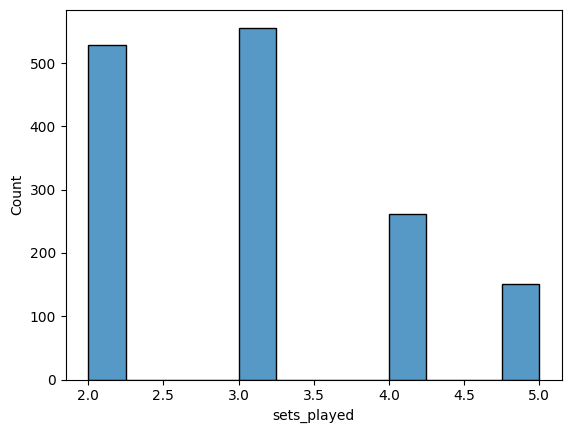

In [ ]:
sns.histplot(match_df['sets_played'])

In [ ]:
# Calculate sets won by each player for each match
sets_won_per_match = df1.groupby(['match_id', 'SetNo'])['SetWinner'].max().reset_index()
p1_sets_won = sets_won_per_match[sets_won_per_match['SetWinner'] == 1].groupby('match_id').size().rename('p1_sets_won')
p2_sets_won = sets_won_per_match[sets_won_per_match['SetWinner'] == 2].groupby('match_id').size().rename('p2_sets_won')

# Merge sets won into the match_df
match_df = match_df.merge(p1_sets_won.reset_index(), on='match_id', how='left').fillna(0)
match_df = match_df.merge(p2_sets_won.reset_index(), on='match_id', how='left').fillna(0)


In [ ]:
match_df['p1_sets_won'].unique()

array([3., 1., 0., 2.])

In [ ]:
match_df['p2_sets_won'].unique()

array([0., 3., 1., 2.])

In [ ]:
p1_serve_count = df1[df1['ServeIndicator'] == 1].groupby('match_id').size().rename('p1_serve_count')
p2_serve_count = df1[df1['ServeIndicator'] == 2].groupby('match_id').size().rename('p2_serve_count')

match_df = match_df.merge(p1_serve_count.reset_index(), on='match_id', how='left').fillna(0)
match_df = match_df.merge(p2_serve_count.reset_index(), on='match_id', how='left').fillna(0)

In [ ]:
# Determine match winner (assuming player with more sets won is the winner)
match_df['match_winner'] = np.where(match_df['p1_sets_won'] > match_df['p2_sets_won'], 1, 2)

In [ ]:
#determin totall points winner
match_df['points_winner'] = np.where(match_df['p1_points_won'] > match_df['p2_points_won'], 1, 2)

In [ ]:
match_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1498 entries, 0 to 1497
Data columns (total 49 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             1498 non-null   object 
 1   points_played        1498 non-null   int64  
 2   rallies_count        1498 non-null   float64
 3   sets_played          1498 non-null   int64  
 4   p1_points_won        1498 non-null   int64  
 5   p2_points_won        1498 non-null   int64  
 6   p1_aces              1498 non-null   int64  
 7   p2_aces              1498 non-null   int64  
 8   p1_winners           1498 non-null   int64  
 9   p2_winners           1498 non-null   int64  
 10  p1_double_faults     1498 non-null   int64  
 11  p2_double_faults     1498 non-null   int64  
 12  p1_unforced_errors   1498 non-null   int64  
 13  p2_unforced_errors   1498 non-null   int64  
 14  p1_net_points        1498 non-null   int64  
 15  p2_net_points        1498 non-null   i

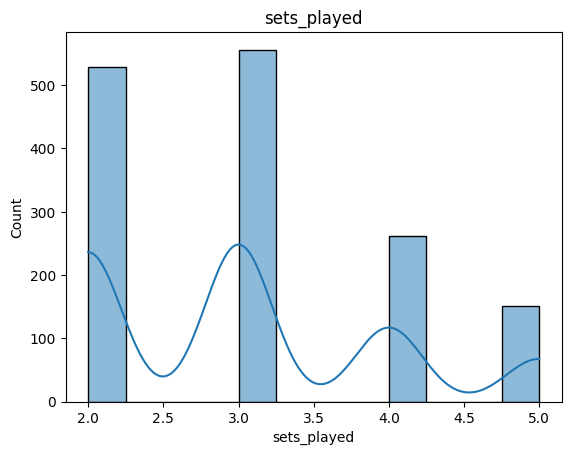

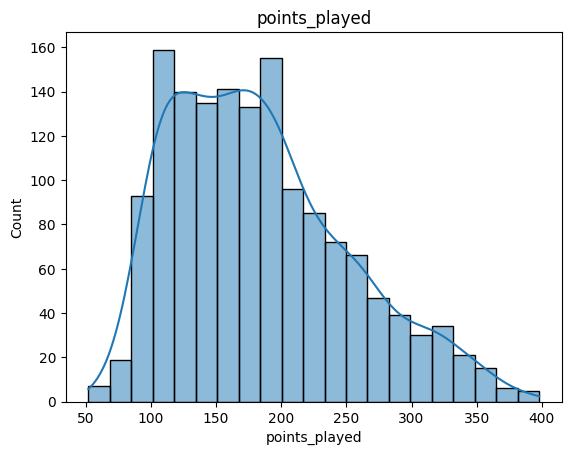

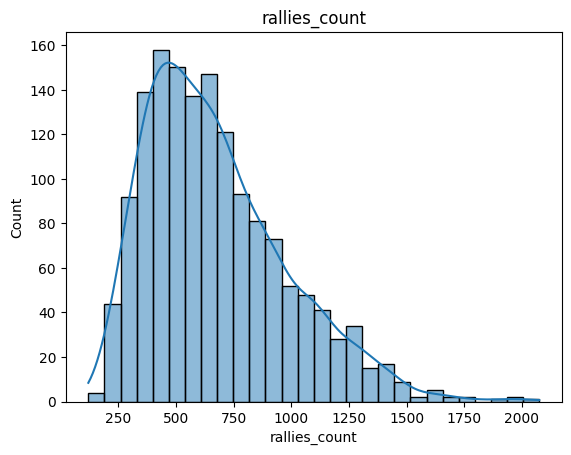

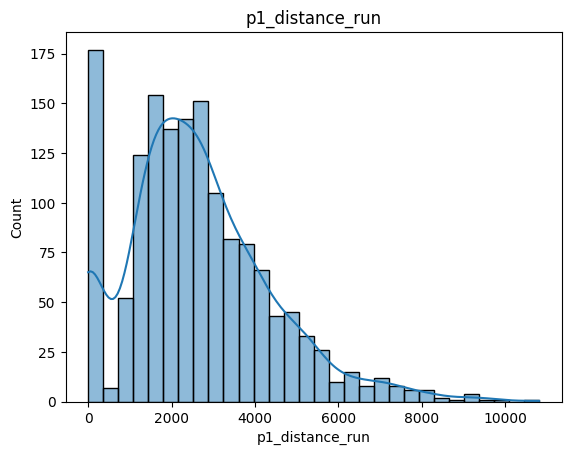

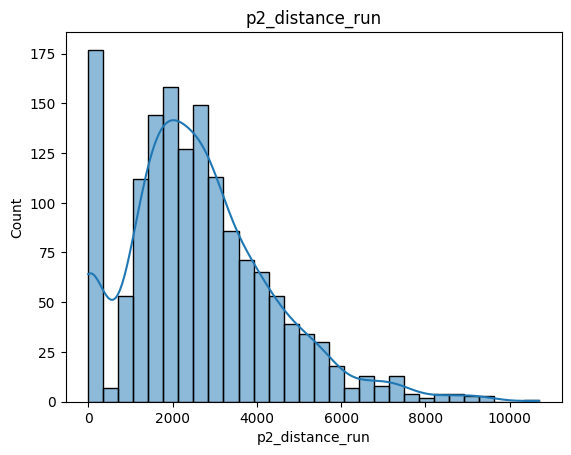

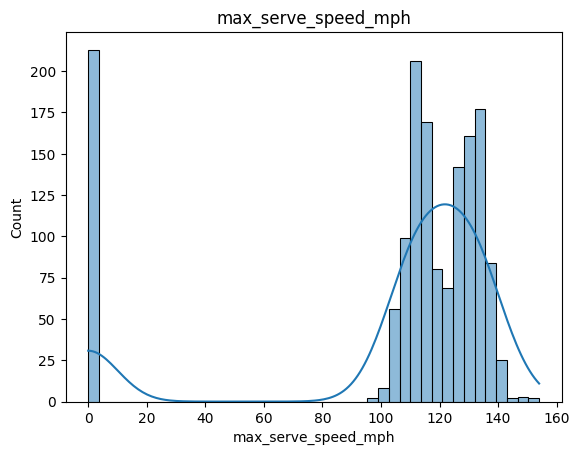

In [ ]:
#check some main statistics to make sure its correct
cols = [
    'sets_played',
    "points_played",
    "rallies_count",
    "p1_distance_run",
    "p2_distance_run",
    'max_serve_speed_mph',
]

for col in cols:
    plt.figure()
    sns.histplot(match_df[col], kde=True)
    plt.title(col)
    plt.show()

In [ ]:
#for the match_df, p1_distance_run, p2_distance_run, and max_serve_speed_mph shouldn't be 0. I'll impute those 0s with the mean of each column.

performance_cols = ['p1_distance_run', 'p2_distance_run', 'max_serve_speed_mph']

for col in performance_cols:
    # Replace 0 with NaN first so they don't affect the mean calculation
    match_df.loc[match_df[col] == 0, col] = np.nan

    # Calculate mean and fill NaNs
    col_mean = match_df[col].mean()
    match_df[col] = match_df[col].fillna(col_mean)
    print(f"Imputed missing values in '{col}' with mean: {col_mean:.2f}")

display(match_df[performance_cols].describe())

Imputed missing values in 'p1_distance_run' with mean: 2952.60
Imputed missing values in 'p2_distance_run' with mean: 2956.91
Imputed missing values in 'max_serve_speed_mph' with mean: 121.91


,p1_distance_run,p2_distance_run,max_serve_speed_mph
count,1498.000000,1498.000000,1498.000000
mean,2952.601103,2956.905014,121.908949
std,1486.775143,1490.192808,9.736486
min,228.919000,242.379000,97.000000
25%,1885.111250,1892.692500,114.000000
50%,2829.806000,2837.643000,121.908949
75%,3560.026750,3537.994500,130.000000
max,10816.690000,10695.361000,154.000000


In [ ]:
match_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1498 entries, 0 to 1497
Data columns (total 49 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             1498 non-null   object 
 1   points_played        1498 non-null   int64  
 2   rallies_count        1498 non-null   float64
 3   sets_played          1498 non-null   int64  
 4   p1_points_won        1498 non-null   int64  
 5   p2_points_won        1498 non-null   int64  
 6   p1_aces              1498 non-null   int64  
 7   p2_aces              1498 non-null   int64  
 8   p1_winners           1498 non-null   int64  
 9   p2_winners           1498 non-null   int64  
 10  p1_double_faults     1498 non-null   int64  
 11  p2_double_faults     1498 non-null   int64  
 12  p1_unforced_errors   1498 non-null   int64  
 13  p2_unforced_errors   1498 non-null   int64  
 14  p1_net_points        1498 non-null   int64  
 15  p2_net_points        1498 non-null   i

In [ ]:

# Safely calculate percentages by handling division by zero
def safe_divide(numerator, denominator):
    return np.where(denominator > 0, numerator / denominator, 0)

# Create percentage stats
match_df['p1_net_win_pct'] = safe_divide(match_df['p1_net_points_won'], match_df['p1_net_points'])
match_df['p2_net_win_pct'] = safe_divide(match_df['p2_net_points_won'], match_df['p2_net_points'])
match_df['p1_break_win_pct'] = safe_divide(match_df['p1_breakpoints_won'], match_df['p1_breakpoints'])
match_df['p2_break_win_pct'] = safe_divide(match_df['p2_breakpoints_won'], match_df['p2_breakpoints'])
match_df['p1_ace_rate'] = safe_divide(match_df['p1_aces'], match_df['p1_serve_count'])
match_df['p2_ace_rate'] = safe_divide(match_df['p2_aces'], match_df['p2_serve_count'])
match_df['p1_df_rate'] = safe_divide(match_df['p1_double_faults'], match_df['points_played'])
match_df['p2_df_rate'] = safe_divide(match_df['p2_double_faults'], match_df['points_played'])
match_df['p1_winner_rate'] = safe_divide(match_df['p1_winners'], match_df['points_played'])
match_df['p2_winner_rate'] = safe_divide(match_df['p2_winners'], match_df['points_played'])
match_df['p1_ue_rate'] = safe_divide(match_df['p1_unforced_errors'], match_df['points_played'])
match_df['p2_ue_rate'] = safe_divide(match_df['p2_unforced_errors'], match_df['points_played'])
match_df['p1_points_win_pct'] = safe_divide(match_df['p1_points_won'], match_df['points_played'])
match_df['p2_points_win_pct'] = safe_divide(match_df['p2_points_won'], match_df['points_played'])
match_df['avg_rally_count'] = safe_divide(match_df['rallies_count'], match_df['points_played'])
match_df['p1_avg_run_distance'] = safe_divide(match_df['p1_distance_run'], match_df['points_played'])
match_df['p2_avg_run_distance'] = safe_divide(match_df['p2_distance_run'], match_df['points_played'])

In [ ]:
#create differences stats because tennis is a relative performance sport
match_df['winner_rate_diff'] = match_df['p1_winner_rate'] - match_df['p2_winner_rate']
match_df['ue_rate_diff'] = match_df['p1_ue_rate'] - match_df['p2_ue_rate']
match_df['ace_rate_diff'] = match_df['p1_ace_rate'] - match_df['p2_ace_rate']
match_df['df_rate_diff'] = match_df['p1_df_rate'] - match_df['p2_df_rate']
match_df['break_win_pct_diff'] = match_df['p1_break_win_pct'] - match_df['p2_break_win_pct']
match_df['net_win_pct_diff'] = match_df['p1_net_win_pct'] - match_df['p2_net_win_pct']
match_df['points_win_pct_diff'] = match_df['p1_points_win_pct'] - match_df['p2_points_win_pct']
match_df['distance_run_diff'] = match_df['p1_avg_run_distance'] - match_df['p2_avg_run_distance']

In [ ]:
# Define the categories of columns we want to keep
pct_cols = [c for c in match_df.columns if '_pct' in c or '_rate' in c or 'avg_' in c]
diff_cols = [c for c in match_df.columns if '_diff' in c]
categ_cols = [c for c in match_df.columns if any(x in c for x in ['ServeWidth', 'ServeDepth', 'ReturnDepth'])]
core_info = ['match_id', 'sets_played', 'points_played', 'rallies_count', 'max_serve_speed_mph', 'match_winner', 'points_winner']

# Combine into a new analysis dataframe and remove duplicate column names
analysis_df = match_df[core_info + pct_cols + diff_cols + categ_cols].copy()
analysis_df = analysis_df.loc[:, ~analysis_df.columns.duplicated()].copy()

print(f"Analysis DataFrame created with {analysis_df.shape[1]} unique features.")
display(analysis_df.head())

Analysis DataFrame created with 50 unique features.


,match_id,sets_played,points_played,rallies_count,max_serve_speed_mph,match_winner,points_winner,p1_net_win_pct,p2_net_win_pct,p1_break_win_pct,...,p2_ServeWidth_C,p2_ServeWidth_W,p1_ServeDepth_CTL,p1_ServeDepth_NCTL,p2_ServeDepth_CTL,p2_ServeDepth_NCTL,p1_ReturnDepth_D,p1_ReturnDepth_ND,p2_ReturnDepth_D,p2_ReturnDepth_ND
0,2019-usopen-1101,3,164,763.876306,126.000000,1,1,0.869565,0.700000,0.363636,...,15,23,26.0,44.0,31,56,22.0,33.0,40,32
1,2019-usopen-1102,4,234,858.720159,136.000000,2,2,0.666667,0.777778,0.600000,...,43,18,44.0,71.0,30,83,23.0,58.0,33,56
2,2019-usopen-1103,4,233,535.587269,121.908949,1,1,0.538462,0.555556,0.333333,...,0,0,0.0,0.0,0,0,0.0,0.0,0,0
3,2019-usopen-1104,3,167,378.892532,121.908949,2,2,0.545455,0.611111,1.000000,...,0,0,0.0,0.0,0,0,0.0,0.0,0,0
4,2019-usopen-1105,4,270,1072.025422,136.000000,1,1,0.533333,0.652174,0.500000,...,20,16,53.0,80.0,32,79,51.0,56.0,44,56


In [ ]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1498 entries, 0 to 1497
Data columns (total 50 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             1498 non-null   object 
 1   sets_played          1498 non-null   int64  
 2   points_played        1498 non-null   int64  
 3   rallies_count        1498 non-null   float64
 4   max_serve_speed_mph  1498 non-null   float64
 5   match_winner         1498 non-null   int64  
 6   points_winner        1498 non-null   int64  
 7   p1_net_win_pct       1498 non-null   float64
 8   p2_net_win_pct       1498 non-null   float64
 9   p1_break_win_pct     1498 non-null   float64
 10  p2_break_win_pct     1498 non-null   float64
 11  p1_ace_rate          1498 non-null   float64
 12  p2_ace_rate          1498 non-null   float64
 13  p1_df_rate           1498 non-null   float64
 14  p2_df_rate           1498 non-null   float64
 15  p1_winner_rate       1498 non-null   f

In [ ]:
analysis_df['match_winner'].unique()

array([1, 2])

In [ ]:
analysis_df['points_winner'].unique()

array([1, 2])

In [ ]:
# Map winner labels from [1, 2] to [1, 0] for binary classification
# Using analysis_df instead of df and using .replace() for pandas compatibility
analysis_df['match_winner'] = analysis_df['match_winner'].replace({2: 0})
analysis_df['points_winner'] = analysis_df['points_winner'].replace({2: 0})

print("Winner labels updated: 1 remains 1, 2 is now 0.")
print(f"Match winner unique values: {analysis_df['match_winner'].unique()}")

Winner labels updated: 1 remains 1, 2 is now 0.
Match winner unique values: [1 0]


In [ ]:
# Identify the base feature names (removing p1_ and p2_ prefixes)
serve_features = ['ServeWidth_B', 'ServeWidth_BC', 'ServeWidth_BW', 'ServeWidth_C', 'ServeWidth_W',
                  'ServeDepth_CTL', 'ServeDepth_NCTL', 'ReturnDepth_D', 'ReturnDepth_ND']

# Create difference columns: Player 1 - Player 2
for feat in serve_features:
    diff_col_name = f'{feat.lower()}_diff'
    analysis_df[diff_col_name] = analysis_df[f'p1_{feat}'] - analysis_df[f'p2_{feat}']
    diff_cols.append(diff_col_name)

In [ ]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1498 entries, 0 to 1497
Data columns (total 59 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   match_id              1498 non-null   object 
 1   sets_played           1498 non-null   int64  
 2   points_played         1498 non-null   int64  
 3   rallies_count         1498 non-null   float64
 4   max_serve_speed_mph   1498 non-null   float64
 5   match_winner          1498 non-null   int64  
 6   points_winner         1498 non-null   int64  
 7   p1_net_win_pct        1498 non-null   float64
 8   p2_net_win_pct        1498 non-null   float64
 9   p1_break_win_pct      1498 non-null   float64
 10  p2_break_win_pct      1498 non-null   float64
 11  p1_ace_rate           1498 non-null   float64
 12  p2_ace_rate           1498 non-null   float64
 13  p1_df_rate            1498 non-null   float64
 14  p2_df_rate            1498 non-null   float64
 15  p1_winner_rate       

In [ ]:
analysis_df['match_id_numeric'] = analysis_df['match_id'].str[-4:].astype(int)
analysis_df['tour'] = np.where(
    (analysis_df['match_id_numeric'] >= 1101) & (analysis_df['match_id_numeric'] <= 1701),
    'atp',
    'wta'
)
analysis_df = analysis_df.drop(columns=['match_id_numeric'])
print(analysis_df[['match_id', 'tour']].head())

           match_id tour
0  2019-usopen-1101  atp
1  2019-usopen-1102  atp
2  2019-usopen-1103  atp
3  2019-usopen-1104  atp
4  2019-usopen-1105  atp


## Save processed dataset

The EDA and modeling notebooks load this file so they can run independently after this notebook has been executed once.

In [ ]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
analysis_df.to_csv(processed_dir / "analysis_df.csv", index=False)
print(f"Saved processed data to {processed_dir / 'analysis_df.csv'}")